<a href="https://colab.research.google.com/github/busykimono/us-wage-inequality-2024/blob/main/wage_inequality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U.S. Wage Inequality by Occupation (2024)
### A data storytelling project using BLS Occupational Employment & Wage Statistics

The United States economy employs over 150 million workers across hundreds of occupations —
but not all jobs are created equal. This analysis explores how wages vary dramatically
across occupations, which jobs sit at the extremes, and what the overall wage landscape
looks like for American workers in 2024.

**Data Source:** U.S. Bureau of Labor Statistics — Occupational Employment and Wage Statistics (OEWS), May 2024  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [2]:
from pathlib import Path
import pandas as pd

data_file = Path('all_data_M_2024.xlsx')
if not data_file.exists():
    raise FileNotFoundError(
        "Missing 'all_data_M_2024.xlsx'. Download it from the BLS OEWS page and place it next to this notebook."
    )

df = pd.read_excel(data_file, sheet_name=0)
df.to_csv('oews_2024.csv', index=False)

In [4]:
print(df.shape)
print(df.head())


(414437, 32)
   AREA AREA_TITLE  AREA_TYPE PRIM_STATE   NAICS     NAICS_TITLE  \
0    99       U.S.          1         US  000000  Cross-industry   
1    99       U.S.          1         US  000000  Cross-industry   
2    99       U.S.          1         US  000000  Cross-industry   
3    99       U.S.          1         US  000000  Cross-industry   
4    99       U.S.          1         US  000000  Cross-industry   

          I_GROUP  OWN_CODE OCC_CODE               OCC_TITLE  ... H_MEDIAN  \
0  cross-industry      1235  00-0000         All Occupations  ...     23.8   
1  cross-industry      1235  11-0000  Management Occupations  ...     58.7   
2  cross-industry      1235  11-1000          Top Executives  ...    50.48   
3  cross-industry      1235  11-1010        Chief Executives  ...    99.24   
4  cross-industry      1235  11-1011        Chief Executives  ...    99.24   

  H_PCT75 H_PCT90 A_PCT10 A_PCT25 A_MEDIAN A_PCT75 A_PCT90 ANNUAL HOURLY  
0   37.89   60.44   29990   36730 

## Data Preparation


In [8]:
df = pd.read_csv('oews_2024.csv', low_memory=False)

cols = ['OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP',
        'A_MEAN', 'A_MEDIAN', 'A_PCT10', 'A_PCT25', 'A_PCT75', 'A_PCT90']

df = df[cols]


In [9]:
# Replace '#' with NaN, then drop rows missing wage data
df.replace('#', pd.NA, inplace=True)

# Convert wage columns to numeric
wage_cols = ['A_MEAN', 'A_MEDIAN', 'A_PCT10', 'A_PCT25', 'A_PCT75', 'A_PCT90']
df[wage_cols] = df[wage_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing median wage
df.dropna(subset=['A_MEDIAN'], inplace=True)

print(df.shape)
print(df.dtypes)
print(df.head())

(407171, 10)
OCC_CODE      object
OCC_TITLE     object
O_GROUP       object
TOT_EMP       object
A_MEAN       float64
A_MEDIAN     float64
A_PCT10      float64
A_PCT25      float64
A_PCT75      float64
A_PCT90      float64
dtype: object
  OCC_CODE               OCC_TITLE   O_GROUP    TOT_EMP    A_MEAN  A_MEDIAN  \
0  00-0000         All Occupations     total  154187380   67920.0   49500.0   
1  11-0000  Management Occupations     major   10966830  141760.0  122090.0   
2  11-1000          Top Executives     minor    3822780  139860.0  104990.0   
3  11-1010        Chief Executives     broad     211850  262930.0  206420.0   
4  11-1011        Chief Executives  detailed     211850  262930.0  206420.0   

   A_PCT10   A_PCT25   A_PCT75   A_PCT90  
0  29990.0   36730.0   78810.0  125720.0  
1  57010.0   79900.0  171610.0       NaN  
2  47510.0   68800.0  168490.0       NaN  
3  73710.0  126080.0       NaN       NaN  
4  73710.0  126080.0       NaN       NaN  


In [10]:
# Fix TOT_EMP - it has commas in numbers like "154,187,380"
df['TOT_EMP'] = df['TOT_EMP'].str.replace(',', '').pipe(pd.to_numeric, errors='coerce')

# Keep only detailed occupations (actual job titles, not roll-ups)
df = df[df['O_GROUP'] == 'detailed']

# Drop remaining rows with missing key values
df.dropna(subset=['A_MEDIAN', 'TOT_EMP'], inplace=True)

print(df.shape)
print(df['O_GROUP'].unique())
print(df.head())


(290303, 10)
['detailed']
   OCC_CODE                            OCC_TITLE   O_GROUP    TOT_EMP  \
4   11-1011                     Chief Executives  detailed   211850.0   
6   11-1021      General and Operations Managers  detailed  3584420.0   
8   11-1031                          Legislators  detailed    26510.0   
11  11-2011  Advertising and Promotions Managers  detailed    21100.0   
13  11-2021                   Marketing Managers  detailed   384980.0   

      A_MEAN  A_MEDIAN  A_PCT10   A_PCT25   A_PCT75   A_PCT90  
4   262930.0  206420.0  73710.0  126080.0       NaN       NaN  
6   133120.0  102950.0  47420.0   67160.0  164130.0       NaN  
8    67390.0   44810.0  20380.0   29120.0   80350.0  137820.0  
11  149270.0  126960.0  63000.0   85990.0  178570.0       NaN  
13  171520.0  161030.0  81900.0  111210.0  211080.0       NaN  


In [11]:
# How many unique detailed occupations are there?
print("Unique occupations:", df['OCC_TITLE'].nunique())

# Basic wage stats
print("\nWage Summary:")
print(df['A_MEDIAN'].describe().apply(lambda x: f"${x:,.0f}"))

# Top 5 highest paying
print("\nTop 5 Highest Paying Occupations:")
print(df.nlargest(5, 'A_MEDIAN')[['OCC_TITLE', 'A_MEDIAN', 'TOT_EMP']])

# Bottom 5 lowest paying
print("\nBottom 5 Lowest Paying Occupations:")
print(df.nsmallest(5, 'A_MEDIAN')[['OCC_TITLE', 'A_MEDIAN', 'TOT_EMP']])

Unique occupations: 825

Wage Summary:
count    $290,303
mean      $64,053
std       $31,027
min       $15,080
25%       $42,490
50%       $56,290
75%       $77,840
max      $239,130
Name: A_MEDIAN, dtype: object

Top 5 Highest Paying Occupations:
                                   OCC_TITLE  A_MEDIAN  TOT_EMP
244153                      Chief Executives  239130.0    870.0
190146         Emergency Medicine Physicians  239100.0    310.0
302135                Pediatricians, General  239080.0     80.0
134945  General Internal Medicine Physicians  238980.0    100.0
199563                 Physicians, All Other  238870.0   7840.0

Bottom 5 Lowest Paying Occupations:
                                           OCC_TITLE  A_MEDIAN  TOT_EMP
144783                   Packers and Packagers, Hand   15080.0    200.0
343219                              Gambling Dealers   15080.0    500.0
343220  Gambling and Sports Book Writers and Runners   15080.0     40.0
287177  Gambling and Sports Book Writers an

In [13]:
# Group by occupation, take the median of wage columns weighted by employment
national = df.groupby('OCC_TITLE').agg(
    TOT_EMP=('TOT_EMP', 'sum'),
    A_MEDIAN=('A_MEDIAN', 'median'),
    A_PCT10=('A_PCT10', 'median'),
    A_PCT90=('A_PCT90', 'median')
).reset_index()

# Drop occupations missing PCT10 or PCT90 (we'll need these for later charts)
national.dropna(subset=['A_PCT10', 'A_PCT90'], inplace=True)

print(national.shape)
print(national.head())

(818, 5)
                                           OCC_TITLE     TOT_EMP  A_MEDIAN  \
0                           Accountants and Auditors  10514870.0   77230.0   
1                                          Actuaries    204100.0  120725.0   
2                                     Acupuncturists     53060.0   78040.0   
3     Adhesive Bonding Machine Operators and Tenders     77970.0   45115.0   
4  Administrative Law Judges, Adjudicators, and H...    120110.0  110300.0   

   A_PCT10   A_PCT90  
0  50490.0  125530.0  
1  75370.0  186850.0  
2  48510.0  139760.0  
3  34875.0   55255.0  
4  64060.0  196120.0  


## 1. The Extremes: Who Earns the Most and Least?

The gap between the highest and lowest paying occupations in the U.S. is striking.
Physicians and executives earn upwards of $200,000 annually, while food service workers,
packagers, and gambling dealers sit at or near the federal minimum wage floor.
The difference between the top and bottom is nearly **15x**.

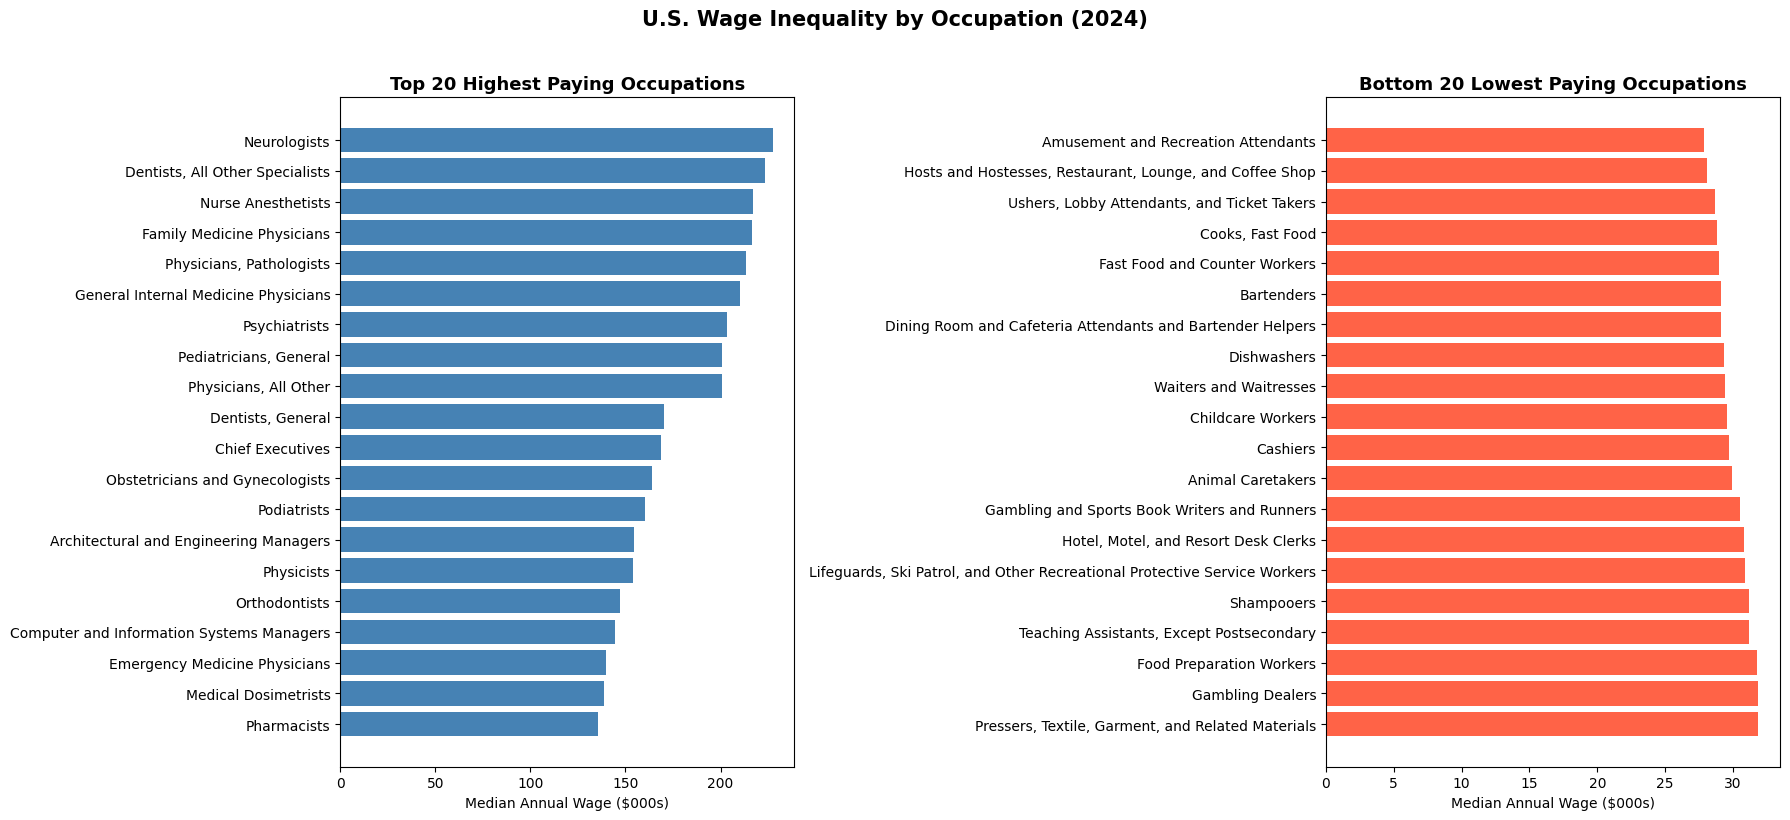

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 20 and bottom 20 by median wage
top20 = national.nlargest(20, 'A_MEDIAN')
bottom20 = national.nsmallest(20, 'A_MEDIAN')

# Combine them
combined = pd.concat([top20, bottom20])
combined['Category'] = ['Top 20'] * 20 + ['Bottom 20'] * 20

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20
axes[0].barh(top20['OCC_TITLE'], top20['A_MEDIAN'] / 1000, color='steelblue')
axes[0].set_title('Top 20 Highest Paying Occupations', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median Annual Wage ($000s)')
axes[0].invert_yaxis()

# Bottom 20
axes[1].barh(bottom20['OCC_TITLE'], bottom20['A_MEDIAN'] / 1000, color='tomato')
axes[1].set_title('Bottom 20 Lowest Paying Occupations', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Annual Wage ($000s)')
axes[1].invert_yaxis()

plt.suptitle('U.S. Wage Inequality by Occupation (2024)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_top_bottom_wages.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Within-Occupation Inequality: How Wide Are Earnings Bands?

Occupation-level medians alone can hide major pay dispersion inside the same role.
This chart compares the 10th and 90th percentiles to show where wage inequality
is widest within a single occupation.


## 2. Within-Occupation Inequality: How Wide Are Earnings Bands?

Occupation-level medians alone can hide major pay dispersion inside the same role.
This chart compares the 10th and 90th percentiles to show where wage inequality
is widest within a single occupation.


## 3. The Big Picture: Where Do Most Workers Land?

Looking across all 818 detailed occupations nationally, the wage distribution
is clearly right-skewed — most occupations cluster below $70,000, while a small
number of high-paying roles pull the mean significantly above the median.
This is the statistical fingerprint of wage inequality: a long tail of elite earners
lifting the average while the typical worker earns considerably less.

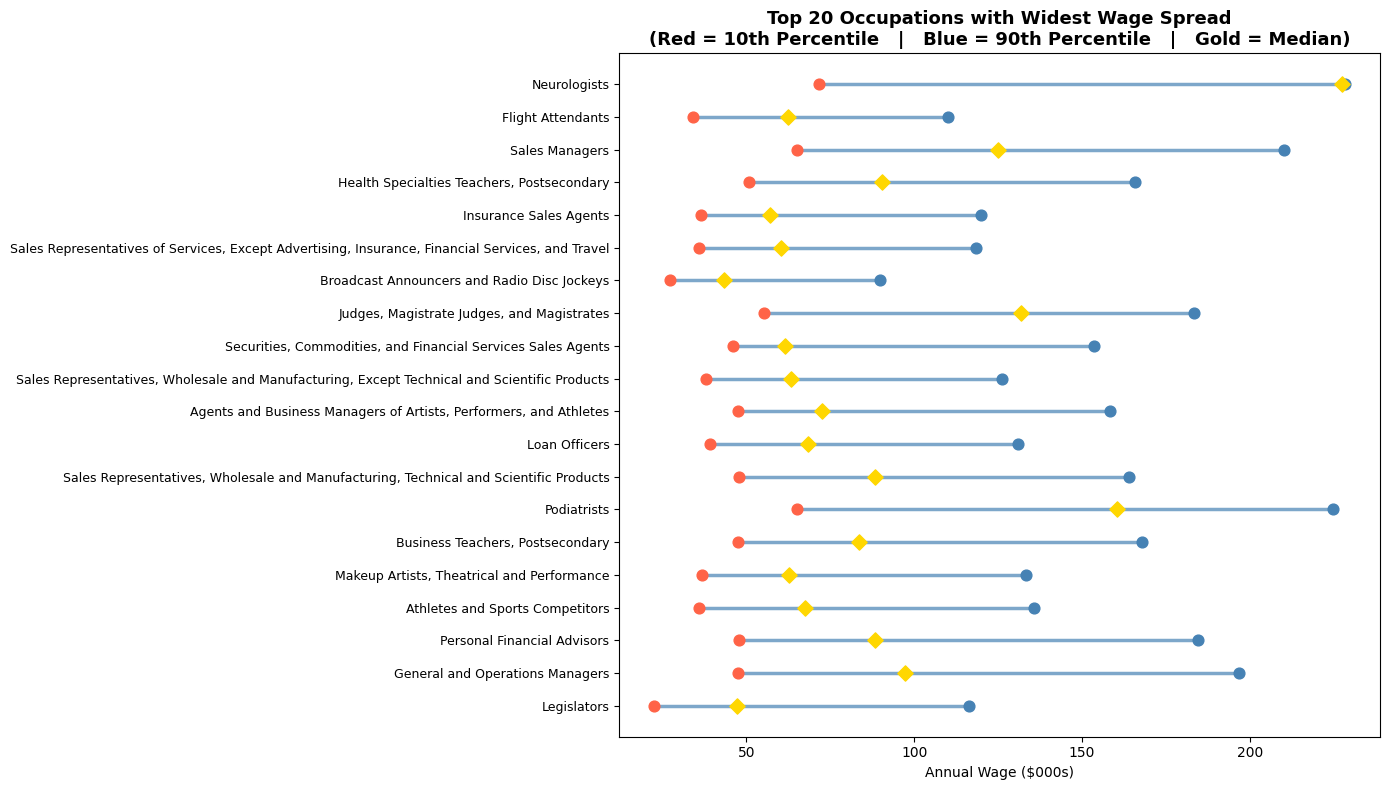

In [16]:
# Calculate wage gap ratio (PCT90 / PCT10) — higher = more unequal
national['wage_gap_ratio'] = national['A_PCT90'] / national['A_PCT10']

# Top 20 most unequal occupations
most_unequal = national.nlargest(20, 'wage_gap_ratio')

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

# Draw a horizontal line from PCT10 to PCT90 for each occupation
for i, row in enumerate(most_unequal.itertuples()):
    ax.plot([row.A_PCT10 / 1000, row.A_PCT90 / 1000], [i, i],
            color='steelblue', linewidth=2.5, alpha=0.7)
    ax.scatter(row.A_PCT10 / 1000, i, color='tomato', zorder=5, s=60)
    ax.scatter(row.A_PCT90 / 1000, i, color='steelblue', zorder=5, s=60)
    ax.scatter(row.A_MEDIAN / 1000, i, color='gold', zorder=5, s=60, marker='D')

ax.set_yticks(range(20))
ax.set_yticklabels(most_unequal['OCC_TITLE'], fontsize=9)
ax.set_xlabel('Annual Wage ($000s)')
ax.set_title('Top 20 Occupations with Widest Wage Spread\n(Red = 10th Percentile   |   Blue = 90th Percentile   |   Gold = Median)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_wage_spread.png', dpi=150, bbox_inches='tight')
plt.show()

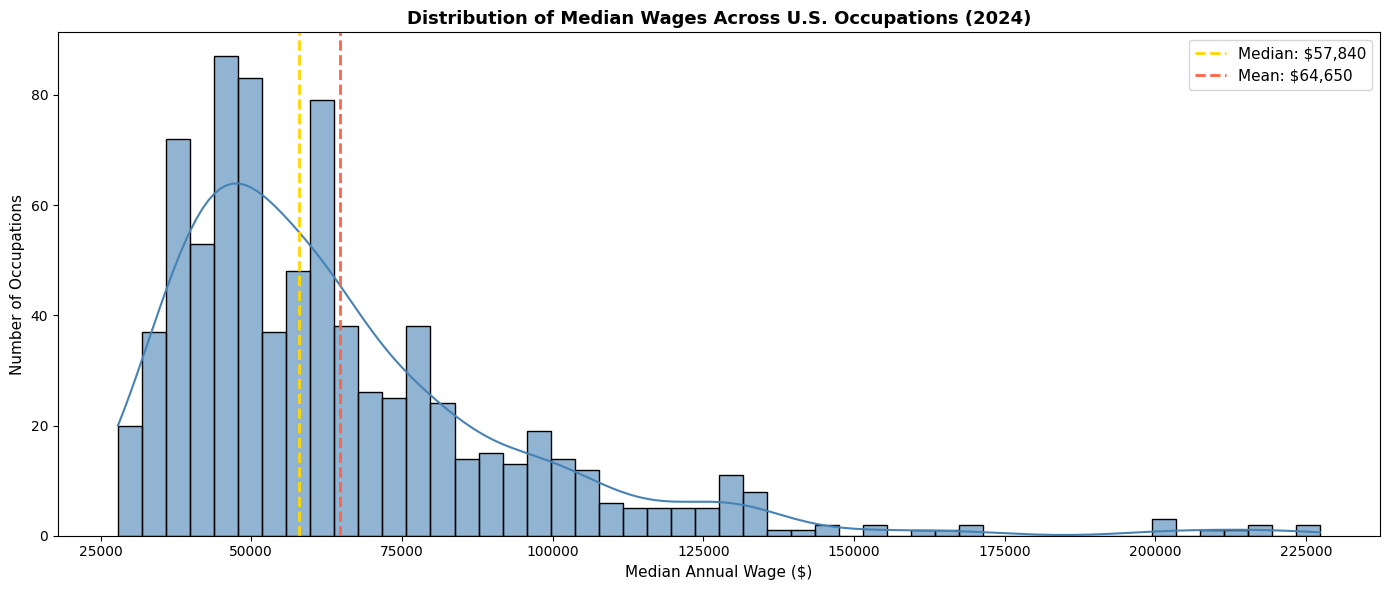

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

# Histogram + density curve
sns.histplot(national['A_MEDIAN'], bins=50, color='steelblue',
             alpha=0.6, kde=True, ax=ax)

# Add vertical reference lines
ax.axvline(national['A_MEDIAN'].median(), color='gold', linewidth=2,
           linestyle='--', label=f"Median: ${national['A_MEDIAN'].median():,.0f}")
ax.axvline(national['A_MEDIAN'].mean(), color='tomato', linewidth=2,
           linestyle='--', label=f"Mean: ${national['A_MEDIAN'].mean():,.0f}")

ax.set_xlabel('Median Annual Wage ($)', fontsize=11)
ax.set_ylabel('Number of Occupations', fontsize=11)
ax.set_title('Distribution of Median Wages Across U.S. Occupations (2024)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart3_wage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Wage Concentration: Who Captures the Wage Bill?

This employment-weighted concentration curve shows how cumulative wage income is
distributed across workers when occupations are ordered from lower to higher median pay.


In [ ]:
# Build an occupation-level wage bill proxy
concentration = national[['OCC_TITLE', 'TOT_EMP', 'A_MEDIAN']].copy()
concentration['wage_bill'] = concentration['TOT_EMP'] * concentration['A_MEDIAN']
concentration = concentration.sort_values('A_MEDIAN').reset_index(drop=True)

concentration['cum_workers'] = concentration['TOT_EMP'].cumsum() / concentration['TOT_EMP'].sum()
concentration['cum_wage_bill'] = concentration['wage_bill'].cumsum() / concentration['wage_bill'].sum()

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(concentration['cum_workers'], concentration['cum_wage_bill'],
        color='steelblue', linewidth=2.5, label='Observed wage concentration')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5,
        label='Perfect equality reference')

ax.set_title('Employment-Weighted Wage Concentration Curve (2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cumulative Share of Workers')
ax.set_ylabel('Cumulative Share of Wage Bill')
ax.legend()

plt.tight_layout()
plt.savefig('chart4_wage_concentration_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Prediction: Estimating Median Wage from Percentile Bands

As a simple predictive baseline, we fit a linear model that estimates each occupation's
median wage using its 10th and 90th percentile wages.


In [ ]:
import numpy as np

model_df = national[['OCC_TITLE', 'A_PCT10', 'A_PCT90', 'A_MEDIAN']].dropna().copy()
X = np.column_stack([
    np.ones(len(model_df)),
    model_df['A_PCT10'].to_numpy(),
    model_df['A_PCT90'].to_numpy()
])
y = model_df['A_MEDIAN'].to_numpy()

coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
model_df['predicted_median'] = X @ coeffs

mae = np.mean(np.abs(model_df['predicted_median'] - y))
ss_res = np.sum((y - model_df['predicted_median']) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"Prediction MAE: ${mae:,.0f}")
print(f"Prediction R²: {r2:.3f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_df['A_MEDIAN'], model_df['predicted_median'], alpha=0.5, color='purple')
line_min = min(model_df['A_MEDIAN'].min(), model_df['predicted_median'].min())
line_max = max(model_df['A_MEDIAN'].max(), model_df['predicted_median'].max())
ax.plot([line_min, line_max], [line_min, line_max], '--', color='gray', linewidth=1.5)

ax.set_title('Predicted vs Actual Median Wage by Occupation', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Median Wage ($)')
ax.set_ylabel('Predicted Median Wage ($)')

plt.tight_layout()
plt.savefig('chart5_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

model_df[['OCC_TITLE', 'A_MEDIAN', 'predicted_median']]\
    .sort_values('A_MEDIAN', ascending=False)\
    .head(10)


## 4. Wage Concentration: Who Captures the Wage Bill?

This employment-weighted concentration curve shows how cumulative wage income is
distributed across workers when occupations are ordered from lower to higher median pay.


In [ ]:
# Build an occupation-level wage bill proxy
concentration = national[['OCC_TITLE', 'TOT_EMP', 'A_MEDIAN']].copy()
concentration['wage_bill'] = concentration['TOT_EMP'] * concentration['A_MEDIAN']
concentration = concentration.sort_values('A_MEDIAN').reset_index(drop=True)

concentration['cum_workers'] = concentration['TOT_EMP'].cumsum() / concentration['TOT_EMP'].sum()
concentration['cum_wage_bill'] = concentration['wage_bill'].cumsum() / concentration['wage_bill'].sum()

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(concentration['cum_workers'], concentration['cum_wage_bill'],
        color='steelblue', linewidth=2.5, label='Observed wage concentration')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5,
        label='Perfect equality reference')

ax.set_title('Employment-Weighted Wage Concentration Curve (2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cumulative Share of Workers')
ax.set_ylabel('Cumulative Share of Wage Bill')
ax.legend()

plt.tight_layout()
plt.savefig('chart4_wage_concentration_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Prediction: Estimating Median Wage from Percentile Bands

As a simple predictive baseline, we fit a linear model that estimates each occupation's
median wage using its 10th and 90th percentile wages.


In [ ]:
import numpy as np

model_df = national[['OCC_TITLE', 'A_PCT10', 'A_PCT90', 'A_MEDIAN']].dropna().copy()
X = np.column_stack([
    np.ones(len(model_df)),
    model_df['A_PCT10'].to_numpy(),
    model_df['A_PCT90'].to_numpy()
])
y = model_df['A_MEDIAN'].to_numpy()

coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
model_df['predicted_median'] = X @ coeffs

mae = np.mean(np.abs(model_df['predicted_median'] - y))
ss_res = np.sum((y - model_df['predicted_median']) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"Prediction MAE: ${mae:,.0f}")
print(f"Prediction R²: {r2:.3f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_df['A_MEDIAN'], model_df['predicted_median'], alpha=0.5, color='purple')
line_min = min(model_df['A_MEDIAN'].min(), model_df['predicted_median'].min())
line_max = max(model_df['A_MEDIAN'].max(), model_df['predicted_median'].max())
ax.plot([line_min, line_max], [line_min, line_max], '--', color='gray', linewidth=1.5)

ax.set_title('Predicted vs Actual Median Wage by Occupation', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Median Wage ($)')
ax.set_ylabel('Predicted Median Wage ($)')

plt.tight_layout()
plt.savefig('chart5_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

model_df[['OCC_TITLE', 'A_MEDIAN', 'predicted_median']]\
    .sort_values('A_MEDIAN', ascending=False)\
    .head(10)


## Key Takeaways

- The U.S. wage gap between occupations is nearly **15x** from bottom to top
- Even within occupations, the spread between low and high earners can exceed **4x**
- The national wage distribution is **right-skewed** — the median worker earns
  significantly less than the mean, pulled up by a small number of elite occupations
- Wage-bill concentration shows a clear imbalance: lower-paid occupations account for a
  larger share of workers than of wage income
- A simple percentile-based linear model can reasonably estimate occupation medians,
  highlighting how strongly median pay tracks lower and upper wage bands

*Analysis by Harrison Okojie | Data: BLS OEWS May 2024*